In [1]:
from datasets import load_dataset
import pandas as pd

In [2]:
# Load dataset
ds = load_dataset("gvlassis/california_housing")

README.md: 0.00B [00:00, ?B/s]

C:\Users\veera\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\veera\.cache\huggingface\hub\datasets--gvlassis--california_housing. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabl

train-00000-of-00001.parquet:   0%|          | 0.00/846k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/106k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16640 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
train_df = pd.DataFrame(ds["train"])
val_df   = pd.DataFrame(ds["validation"])
test_df  = pd.DataFrame(ds["test"])

print(train_df.shape, val_df.shape, test_df.shape)

(16640, 9) (2000, 9) (2000, 9)


In [ ]:
"""
The dataset already has training, validation, and test splits. 
These splits are used directly to train and evaluate the model, so there is no need for manual data splitting. This ensures proper evaluation without data leakage. """

In [6]:
X_train = train_df.drop(columns=["MedHouseVal"])
y_train = train_df["MedHouseVal"]

X_val = val_df.drop(columns=["MedHouseVal"])
y_val = val_df["MedHouseVal"]

X_test = test_df.drop(columns=["MedHouseVal"])
y_test = test_df["MedHouseVal"]

print(X_train.shape, y_train.shape)

(16640, 8) (16640,)


In [ ]:
"""
The Features (X) are things that describe a district: 
MedInc, HouseAge, AveRooms, Population, Latitude, Longitude

The Target (y): What will be predicted:
MedHouseVal (median house value)

These need to be seperated so model doesn't accidently see the answer before prediction. 
"""

In [7]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

In [8]:
# Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
# Predict on test data
y_pred = model.predict(X_test)

# check
print(y_pred[:5])

[2.2602763  2.38499843 2.8276692  2.22615414 2.4441879 ]


In [ ]:
"""
A Linear Regression model trained using the predefined training split provided by the dataset.
"""

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

Mean Absolute Error (MAE): 0.42974235108614833
Mean Squared Error (MSE): 0.34156478857966727


In [ ]:
"""
MAE ≈ 0.43
MSE ≈ 0.34

Since the target variable represents house value in units of $100,000, the MAE corresponds to an average prediction error of approximately $43,000. 
So the model captures general trends but has limited precision, which is expected for a simple linear model. """

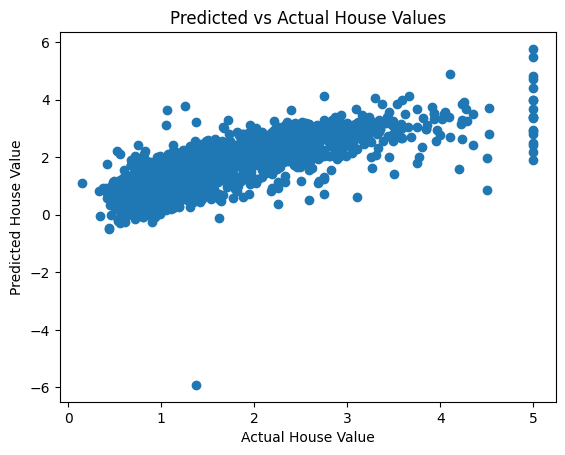

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual House Values")
plt.show()

In [ ]:
"""
What plot shows: 
- Clear trend: As actual house value increases, predicted value also increases
- Wide spread around the diagonal: prediction error 
- At high actual values (near 5.0), predictions flatten. The model struggles to predict very expensive homes accurately
"""